# Fashion MNIST Classification with CNN (TensorFlow + Keras)

# Phase 1: Imports and configuration setup

In [1]:
"""
Convolutional Neural Network for Image Classification on the Fashion MNIST Dataset.

This notebook trains a CNN using TensorFlow and Keras to classify grayscale images
of fashion items into one of 10 predefined categories, such as T-shirts, trousers,
and sneakers. The model architecture includes convolutional, pooling, dropout, and
dense layers, followed by training and evaluation using categorical cross-entropy
and accuracy metrics.

Features:
- Uses Fashion MNIST dataset (60,000 train / 10,000 test images)
- Includes one-hot encoding of labels and normalization of pixel values
- Implements dropout for regularization
- Evaluates model performance with precision, recall, and F1-score

Designed for portfolio demonstration of computer vision fundamentals using Keras.
"""

import pandas as pd
import numpy as np
import re
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.src.utils.module_utils import tensorflow  # keep if needed
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Input, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.datasets import fashion_mnist

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score,     mean_squared_error, root_mean_squared_error, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings('ignore')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(e)

tf.config.threading.set_intra_op_parallelism_threads(32)
tf.config.threading.set_inter_op_parallelism_threads(32)


2025-05-02 21:48:56.141143: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-02 21:48:56.149084: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746247736.157388  873480 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746247736.159974  873480 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746247736.166954  873480 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

GPU memory growth enabled


# Phase 2: Load and visualize dataset

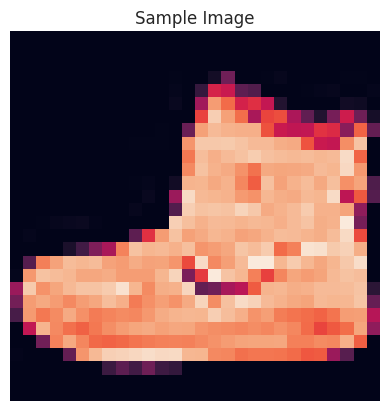

In [2]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

plt.imshow(x_train[0])
plt.title("Sample Image")
plt.axis('off')
plt.show()


# Phase 3: Preprocessing data

In [3]:
x_train = x_train / 255
x_test = x_test / 255

x_train = x_train.reshape(60000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)

y_cat_train = to_categorical(y_train, 10)
y_cat_test = to_categorical(y_test, 10)


# Phase 4: Build and compile CNN model

In [4]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(4,4), input_shape=(28,28,1), activation="relu"))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dense(10, activation="softmax"))

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()


I0000 00:00:1746247737.653989  873480 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21254 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 25, 25, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 591,786 (2.26 MB)

 Trainable params: 591,786 (2.26 MB)

 Non-trainable params: 0 (0.00 B)

# Phase 5: Train the model

In [5]:
history = model.fit(
    x_train, y_cat_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_test, y_cat_test),
)


Epoch 1/10


I0000 00:00:1746247738.638019  873640 service.cc:152] XLA service 0x7bcd90004250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746247738.638032  873640 service.cc:160]   StreamExecutor device (0): NVIDIA RTX A5000, Compute Capability 8.6
2025-05-02 21:48:58.650103: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1746247738.711841  873640 cuda_dnn.cc:529] Loaded cuDNN version 90800
2025-05-02 21:48:59.117754: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_525', 4 bytes spill stores, 4 bytes spill loads



 206/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 736us/step - accuracy: 0.6480 - loss: 1.0156

I0000 00:00:1746247739.913087  873640 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8079 - loss: 0.5441 - val_accuracy: 0.8819 - val_loss: 0.3294
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 796us/step - accuracy: 0.8900 - loss: 0.3039 - val_accuracy: 0.8967 - val_loss: 0.2850
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 807us/step - accuracy: 0.9092 - loss: 0.2463 - val_accuracy: 0.9018 - val_loss: 0.2711
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 809us/step - accuracy: 0.9158 - loss: 0.2225 - val_accuracy: 0.9101 - val_loss: 0.2562
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 844us/step - accuracy: 0.9262 - loss: 0.1966 - val_accuracy: 0.9065 - val_loss: 0.2680
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 823us/step - accuracy: 0.9316 - loss: 0.1798 - val_accuracy: 0.9091 - val_loss: 0.2492
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - accuracy: 0.9376 - loss: 0.1647 - val_accuracy: 0.9128 - val_loss: 0.2529
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 824us/step - accuracy: 0.9456 - loss: 0.1458

# Phase 6: Evaluate performance and metrics

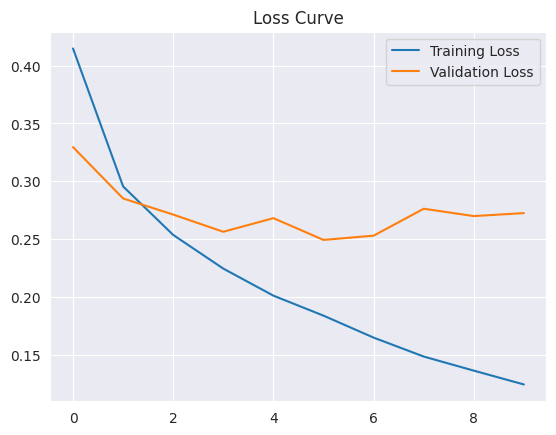

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 579us/step - accuracy: 0.9135 - loss: 0.2829
Test Loss: 0.2723948657512665
Test Accuracy: 0.9168000221252441
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 899us/step
Precision: 0.9165153576782074
Recall: 0.9168
F1-score: 0.916463088564208


In [6]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

test_loss, test_accuracy = model.evaluate(x_test, y_cat_test)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_cat_test, axis=1)

precision = precision_score(y_true_classes, y_pred_classes, average='weighted')
recall = recall_score(y_true_classes, y_pred_classes, average='weighted')
f1 = f1_score(y_true_classes, y_pred_classes, average='weighted')

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")


# Phase 7: Notebook complete
Model training and evaluation pipeline finished.